In [ ]:

import re
import string
import time

from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from bs4 import BeautifulSoup
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping


sns.set(style='whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

In [ ]:
# Download small NLTK resources needed for tokenisation, stop words, and lemmatisation.
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

1.Load dataset

In [ ]:
# Load IMDB dataset

import pandas as pd
from tensorflow.keras.datasets import imdb

# Load dataset
(X_train, y_train), (X_test, y_test) = imdb.load_data()

# Get word dictionary
word_index = imdb.get_word_index()

# Reverse dictionary
reverse_word_index = {
    value: key for key, value in word_index.items()
}

# Function to convert numbers back to words
def decode_review(review):

    words = []

    for i in review:

        if i in reverse_word_index:
            words.append(reverse_word_index[i])

    return " ".join(words)

# Decode reviews
reviews = []

for review in X_train:

    reviews.append(decode_review(review))

# Create DataFrame
df = pd.DataFrame({
    'review': reviews,
    'label': y_train
})

# Convert labels
df['sentiment'] = df['label'].map({
    0: 'negative',
    1: 'positive'
})

# Display shape
print(df.shape)

# Display first 5 rows
df.head()

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(25000, 3)


,review,label,sentiment
0,the as you with out themselves powerful lets l...,1,positive
1,the thought solid thought senator do making to...,0,negative
2,the as there in at by br of sure many br of pr...,0,negative
3,the of bernadette mon they halfway of identity...,1,positive
4,the sure themes br only acting i i was favouri...,0,negative


**2. text preprocessing**

1.   lowercase
2.   remove HTML tags
3.   remove punctuations
4.   tokenise
5.   remove stop words
6.   Lemmatise



In [ ]:
stop_words = set(stopwords.words('english'))

# Keep negation words because they can reverse sentiment.
negation_words = {'no', 'not', 'nor', 'never', 'none', 'cannot', "don't", "didn't", "wasn't", "isn't"}
stop_words = stop_words - negation_words

lemmatizer = WordNetLemmatizer()

def clean_review(text):
    """Clean one review and return a preprocessed string."""
    text = BeautifulSoup(str(text), 'html.parser').get_text(separator=' ')
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(tokens)

df['clean_review'] = df['review'].apply(clean_review)
df[['review', 'clean_review', 'sentiment']].head()

,review,clean_review,sentiment
0,the as you with out themselves powerful lets l...,powerful let love becomes reaching journalist ...,positive
1,the thought solid thought senator do making to...,thought solid thought senator making spot nomi...,negative
2,the as there in at by br of sure many br of pr...,sure many proving woman never hat night ignore...,negative
3,the of bernadette mon they halfway of identity...,bernadette mon halfway identity went plot acto...,positive
4,the sure themes br only acting i i was favouri...,sure theme acting favourite hat already scare ...,negative


In [ ]:
# Print 3 examples side by side.
examples = df[['review', 'clean_review', 'sentiment']].sample(3, random_state=RANDOM_STATE)

for i, row in examples.iterrows():
    print('=' * 100)
    print('Sentiment:', row['sentiment'])
    print('\nOriginal review:\n', row['review'][:800])
    print('\nCleaned review:\n', row['clean_review'][:800])

Sentiment: negative

Original review:
 the music is word followed may ordeal so i've hidden loud br man irritating hero interest dealt to early just nightmare ol' troubles to be ways one bit film criminals disc to else sci just that of you tone strange weren't ballads first is criminals this of bother for effort in mission picking movie by watch of because biopics in as hey future love bear lacking investigation if his both new of women i'd are by funny to well questions bunch of deeply br by funny get read pretty in at this of every abrahams movie any movie ghosts movie that an whom music is soundtrack adopted side of german surprise br as you for after one unique this of previous br is read suspended nightmare  when bad here she film it zombie door films david minimal thinks horror in at in few version they of 5 in could of 

Cleaned review:
 music word followed may ordeal hidden loud man irritating hero interest dealt early nightmare trouble way one bit film criminal disc else sci 

3.Exploratory Data Analysis

sentiment
positive    12500
negative    12500
Name: count, dtype: int64


/tmp/ipykernel_2413/3321281849.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment', palette='Set2')


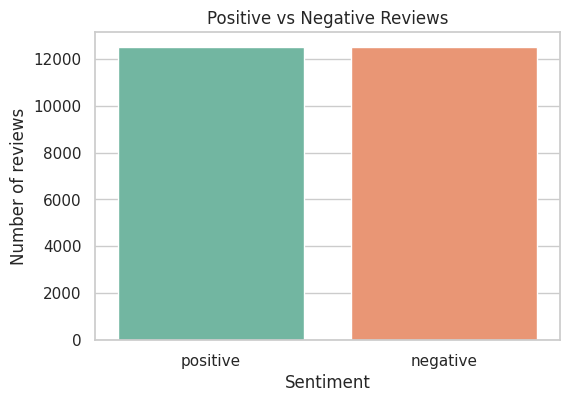

Observation: The dataset is balanced.


In [ ]:
sentiment_counts = df['sentiment'].value_counts()
print(sentiment_counts)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='sentiment', palette='Set2')
plt.title('Positive vs Negative Reviews')
plt.xlabel('Sentiment')
plt.ylabel('Number of reviews')
plt.show()

if sentiment_counts.min() / sentiment_counts.max() > 0.9:
    print('Observation: The dataset is balanced.')
else:
    print('Observation: The dataset is not perfectly balanced.')

Average length before cleaning: 238.7148
Average length after cleaning: 121.15128


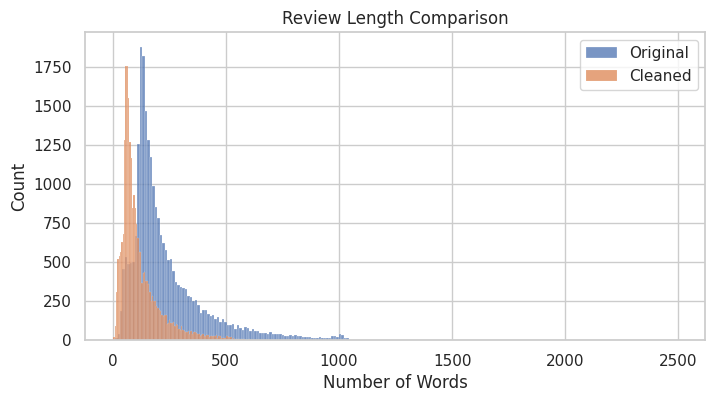

In [ ]:
# Count words in original reviews
df['original_length'] = df['review'].apply(
    lambda x: len(x.split())
)

# Count words in cleaned reviews
df['clean_length'] = df['clean_review'].apply(
    lambda x: len(x.split())
)

# Print average lengths
print("Average length before cleaning:",
      df['original_length'].mean())

print("Average length after cleaning:",
      df['clean_length'].mean())

# Plot graph
plt.figure(figsize=(8,4))

# Original review lengths
sns.histplot(
    df['original_length'],
    label='Original'
)

# Cleaned review lengths
sns.histplot(
    df['clean_length'],
    label='Cleaned'
)

# Graph labels
plt.title("Review Length Comparison")
plt.xlabel("Number of Words")

# Show legend
plt.legend()

# Show graph
plt.show()

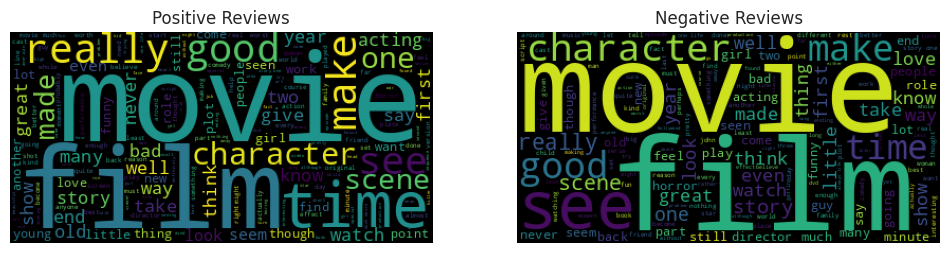

In [ ]:
# Combine all positive reviews into one text
positive_text = ' '.join(
    df[df['sentiment'] == 'positive']['clean_review']
)

# Combine all negative reviews into one text
negative_text = ' '.join(
    df[df['sentiment'] == 'negative']['clean_review']
)

# Create figure
plt.figure(figsize=(12,5))

# Positive word cloud
plt.subplot(1,2,1)

positive_cloud = WordCloud().generate(positive_text)

plt.imshow(positive_cloud)

plt.axis('off')

plt.title("Positive Reviews")

# Negative word cloud
plt.subplot(1,2,2)

negative_cloud = WordCloud().generate(negative_text)

plt.imshow(negative_cloud)

plt.axis('off')

plt.title("Negative Reviews")

# Show graphs
plt.show()

/tmp/ipykernel_2413/3547403008.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_words_df, y='word', x='count', palette='viridis')


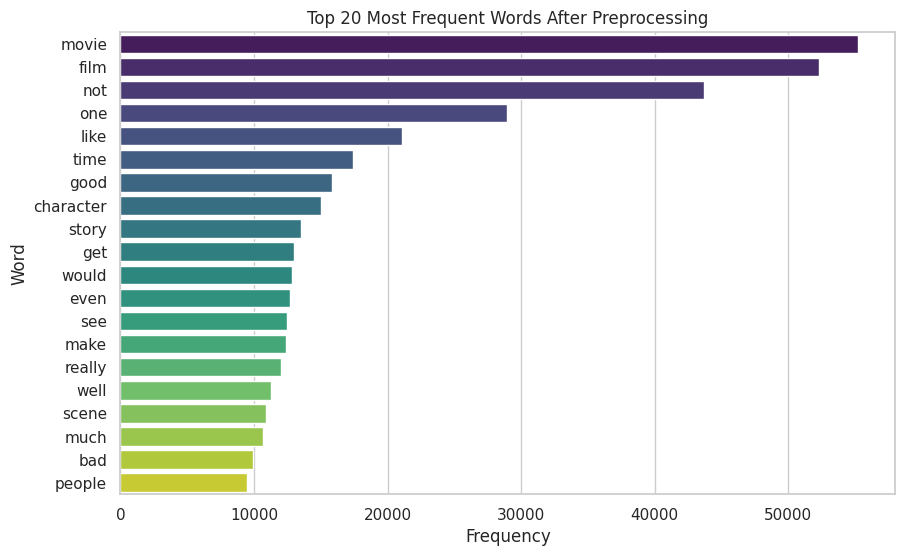

,word,count
0,movie,55252
1,film,52268
2,not,43717
3,one,28962
4,like,21075
5,time,17417
6,good,15847
7,character,15045
8,story,13526
9,get,13034


In [ ]:
all_words = ' '.join(df['clean_review']).split()
top_20_words = Counter(all_words).most_common(20)
top_words_df = pd.DataFrame(top_20_words, columns=['word', 'count'])

plt.figure(figsize=(10, 6))
sns.barplot(data=top_words_df, y='word', x='count', palette='viridis')
plt.title('Top 20 Most Frequent Words After Preprocessing')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.show()

top_words_df

4.Text  representation

In [ ]:
X = df['clean_review']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print('Training reviews:', X_train.shape[0])
print('Testing reviews:', X_test.shape[0])

Training reviews: 20000
Testing reviews: 5000


In [ ]:
# TF-IDF representation for Logistic Regression.
# max_features keeps the model simple and memory-friendly.
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print('TF-IDF train shape:', X_train_tfidf.shape)
print('TF-IDF test shape:', X_test_tfidf.shape)

TF-IDF train shape: (20000, 10000)
TF-IDF test shape: (5000, 10000)


In [ ]:
# Print TF-IDF scores for 5 words in one review.
sample_index = 0
sample_review = X_test.iloc[sample_index]
sample_vector = tfidf.transform([sample_review])

feature_names = np.array(tfidf.get_feature_names_out())
non_zero_indices = sample_vector.nonzero()[1]
scores = sample_vector.data

score_df = pd.DataFrame({
    'word_or_phrase': feature_names[non_zero_indices],
    'tfidf_score': scores
}).sort_values(by='tfidf_score', ascending=False)

print('Sample cleaned review:')
print(sample_review[:1000])
print('\nTop 5 TF-IDF scores in this review:')
display(score_df.head(5))

Sample cleaned review:
problem hell warm catch necessary chance gael sex hundstage success boa daughter awesome present must story director read comparison series musical obvious ever comedy hitler jones propels worth way time top pregnant studio powerful move scene emmanuel troubled face watch really say three movie movie hollywood convicted cast yet trip jimmy saw stuff though like boa going elite finlay associate print mindset mindset world disciplining kind piece scene going not alive like supposed face whole hoped help whether basanti audience ken mind compared oriented well legless art movie theater violence audience sake folk cause rank normally nearly woman weirdo recitation mate killer blouse tabloid pasture saw like nothing form film tabloid would anyone smartly william film history damn profession come reality bad showing eye made law best not comedy yasuzo pegged ive breathtaking primarily damn technically away funny messed natural john perfectly smartly acting look psycho 

,word_or_phrase,tfidf_score
114,gino,0.264307
148,ken,0.243958
139,inconsistent,0.160570
322,troubled,0.133345
88,ever,0.129232


In [ ]:
# Word embedding representation for LSTM.
# We use integer sequences first, then the Embedding layer learns dense word vectors.

MAX_WORDS = 20000
MAX_LEN = 200

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

print('Padded training shape:', X_train_pad.shape)
print('Padded testing shape:', X_test_pad.shape)

Padded training shape: (20000, 200)
Padded testing shape: (5000, 200)


5. Build Two models

In [ ]:
def evaluate_model(model_name, y_true, y_pred):
    """Calculate and print common classification metrics."""
    metrics = {
        'model': model_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1_score': f1_score(y_true, y_pred)
    }
    print(model_name)
    print(classification_report(y_true, y_pred, target_names=['negative', 'positive']))
    return metrics

def plot_confusion_matrix(y_true, y_pred, title):
    """Plot a confusion matrix with readable class labels."""
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['negative', 'positive'], yticklabels=['negative', 'positive'], ax=ax)
    plt.title(title)
    plt.xlabel('Predicted label')
    plt.ylabel('Actual label')
    plt.show()
    return cm

Model 1 : Logistic Regression with TF-IDF

Logistic Regression + TF-IDF
              precision    recall  f1-score   support

    negative       0.88      0.85      0.87      2500
    positive       0.86      0.88      0.87      2500

    accuracy                           0.87      5000
   macro avg       0.87      0.87      0.87      5000
weighted avg       0.87      0.87      0.87      5000



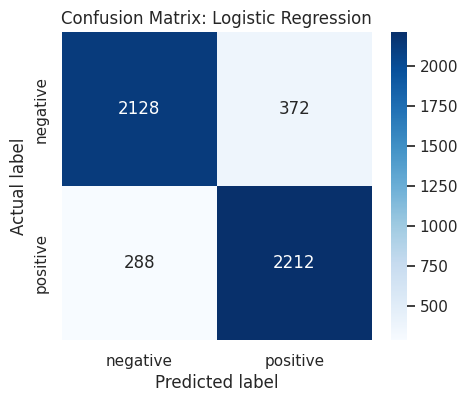

Training time in seconds: 0.17


In [ ]:
start_time = time.time()

log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_tfidf, y_train)

log_reg_train_time = time.time() - start_time
log_reg_pred = log_reg.predict(X_test_tfidf)

log_reg_metrics = evaluate_model('Logistic Regression + TF-IDF', y_test, log_reg_pred)
log_reg_cm = plot_confusion_matrix(y_test, log_reg_pred, 'Confusion Matrix: Logistic Regression')

print('Training time in seconds:', round(log_reg_train_time, 2))

Model 2 : LSTM with embedding layer

Text → Tokens → Embedding → BiLSTM → Dense → Output

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout, Bidirectional

EMBEDDING_DIM = 50

lstm_model = Sequential([
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LEN,
        mask_zero=True,
        embeddings_regularizer=tf.keras.regularizers.l2(0.0005)
    ),
    Bidirectional(LSTM(
        16,
        dropout=0.5,
        recurrent_dropout=0.4,
        kernel_regularizer=tf.keras.regularizers.l2(0.001),
        recurrent_regularizer=tf.keras.regularizers.l2(0.001)
    )),
    Dense(8, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    Dropout(0.6),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_model.build(input_shape=(None, MAX_LEN))
lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 50)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 32)             │         8,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,008,849 (3.85 MB)

 Trainable params: 1,008,849 (3.85 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
start_time = time.time()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=1,
    min_delta=0.001,
    restore_best_weights=True
)

history = lstm_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=6,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

lstm_train_time = time.time() - start_time
print('Training time in seconds:', round(lstm_train_time, 2))


Epoch 1/6
125/125 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.5813 - loss: 0.8209 - val_accuracy: 0.8067 - val_loss: 0.6223
Epoch 2/6
125/125 ━━━━━━━━━━━━━━━━━━━━ 119s 955ms/step - accuracy: 0.7785 - loss: 0.5939 - val_accuracy: 0.8443 - val_loss: 0.4978
Epoch 3/6
125/125 ━━━━━━━━━━━━━━━━━━━━ 120s 964ms/step - accuracy: 0.8291 - loss: 0.5274 - val_accuracy: 0.8465 - val_loss: 0.4850
Epoch 4/6
125/125 ━━━━━━━━━━━━━━━━━━━━ 121s 971ms/step - accuracy: 0.8499 - loss: 0.4996 - val_accuracy: 0.8317 - val_loss: 0.5031
Training time in seconds: 520.55


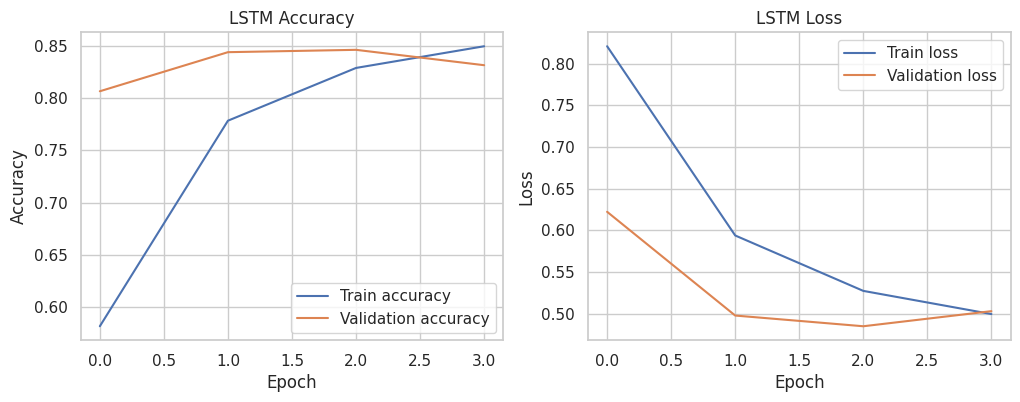

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.title('LSTM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('LSTM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

157/157 ━━━━━━━━━━━━━━━━━━━━ 48s 301ms/step
LSTM + Embedding
              precision    recall  f1-score   support

    negative       0.87      0.80      0.83      2500
    positive       0.81      0.88      0.84      2500

    accuracy                           0.84      5000
   macro avg       0.84      0.84      0.84      5000
weighted avg       0.84      0.84      0.84      5000



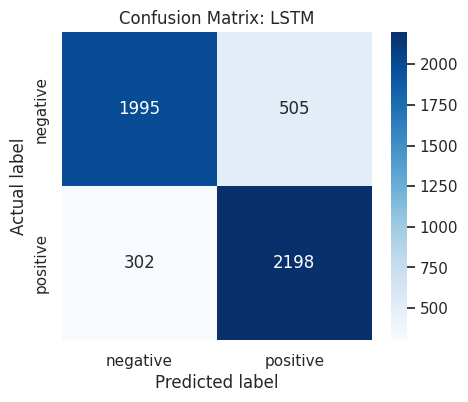

Training time in seconds: 520.55


In [ ]:
lstm_prob = lstm_model.predict(X_test_pad)
lstm_pred = (lstm_prob >= 0.5).astype(int).reshape(-1)

lstm_metrics = evaluate_model('LSTM + Embedding', y_test, lstm_pred)
lstm_cm = plot_confusion_matrix(y_test, lstm_pred, 'Confusion Matrix: LSTM')

print('Training time in seconds:', round(lstm_train_time, 2))

6.compare both models

In [ ]:
log_reg_metrics['training_time_seconds'] = log_reg_train_time
lstm_metrics['training_time_seconds'] = lstm_train_time

results_df = pd.DataFrame([log_reg_metrics, lstm_metrics])
results_df[['model', 'accuracy', 'precision', 'recall', 'f1_score', 'training_time_seconds']]

,model,accuracy,precision,recall,f1_score,training_time_seconds
0,Logistic Regression + TF-IDF,0.8680,0.856037,0.8848,0.870181,0.173844
1,LSTM + Embedding,0.8386,0.813171,0.8792,0.844897,520.554194


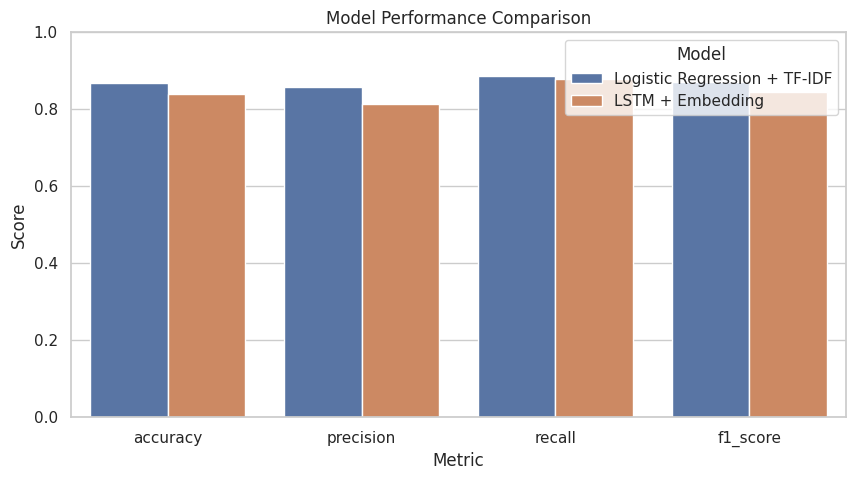

/tmp/ipykernel_2413/216431495.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='model', y='training_time_seconds', palette='Set3')


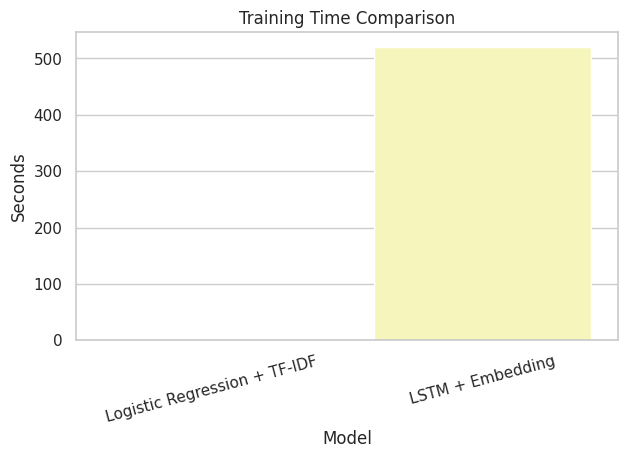

In [ ]:
plt.figure(figsize=(10, 5))
metrics_to_plot = results_df.melt(id_vars='model', value_vars=['accuracy', 'precision', 'recall', 'f1_score'])
sns.barplot(data=metrics_to_plot, x='variable', y='value', hue='model')
plt.title('Model Performance Comparison')
plt.ylim(0, 1)
plt.xlabel('Metric')
plt.ylabel('Score')
plt.legend(title='Model')
plt.show()

plt.figure(figsize=(7, 4))
sns.barplot(data=results_df, x='model', y='training_time_seconds', palette='Set3')
plt.title('Training Time Comparison')
plt.xlabel('Model')
plt.ylabel('Seconds')
plt.xticks(rotation=15)
plt.show()

In [ ]:
best_model_name = results_df.sort_values(by='f1_score', ascending=False).iloc[0]['model']
print('Best model by F1 score:', best_model_name)

if best_model_name == 'Logistic Regression + TF-IDF':
    best_pred = log_reg_pred
    best_prob = log_reg.predict_proba(X_test_tfidf)[:, 1]
else:
    best_pred = lstm_pred
    best_prob = lstm_prob.reshape(-1)

comparison_df = pd.DataFrame({
    'review': X_test.values,
    'actual': y_test.values,
    'predicted': best_pred,
    'positive_probability': best_prob
})

wrong_examples = comparison_df[comparison_df['actual'] != comparison_df['predicted']].copy()
wrong_examples['actual_sentiment'] = wrong_examples['actual'].map({0: 'negative', 1: 'positive'})
wrong_examples['predicted_sentiment'] = wrong_examples['predicted'].map({0: 'negative', 1: 'positive'})

wrong_examples[['review', 'actual_sentiment', 'predicted_sentiment', 'positive_probability']].head(3)

Best model by F1 score: Logistic Regression + TF-IDF


,review,actual_sentiment,predicted_sentiment,positive_probability
7,photography eye event cgi march idea treatment...,negative,positive,0.636915
29,interesting funny overshadows thirty not girl ...,positive,negative,0.401166
31,much interesting musical make believable appea...,positive,negative,0.487694


In [ ]:
best_cm = confusion_matrix(y_test, best_pred)
tn, fp, fn, tp = best_cm.ravel()

print('True negatives:', tn)
print('False positives:', fp)
print('False negatives:', fn)
print('True positives:', tp)

if fp > fn:
    print('False positives are more common.')
elif fn > fp:
    print('False negatives are more common.')
else:
    print('False positives and false negatives are equally common.')

True negatives: 2128
False positives: 372
False negatives: 288
True positives: 2212
False positives are more common.


7. Test With Your Own Sample Review

In [ ]:
sample_review = "The movie had a slow start, but the story became emotional and the acting was excellent. I really enjoyed it."


In [ ]:
# Clean the sample review using the same preprocessing function
sample_clean_review = clean_review(sample_review)

print('Original review:')
print(sample_review)

print('\nCleaned review:')
print(sample_clean_review)


Original review:
The movie had a slow start, but the story became emotional and the acting was excellent. I really enjoyed it.

Cleaned review:
movie slow start story became emotional acting excellent really enjoyed


In [ ]:
if best_model_name == 'Logistic Regression + TF-IDF':
    sample_vector = tfidf.transform([sample_clean_review])
    sample_probability = log_reg.predict_proba(sample_vector)[0][1]
else:
    sample_sequence = tokenizer.texts_to_sequences([sample_clean_review])
    sample_padded = pad_sequences(
        sample_sequence,
        maxlen=MAX_LEN,
        padding='post',
        truncating='post'
    )
    sample_probability = lstm_model.predict(sample_padded)[0][0]

sample_label = 'positive' if sample_probability >= 0.5 else 'negative'

print('Best model used:', best_model_name)
print('Predicted sentiment:', sample_label)
print('Positive probability:', round(float(sample_probability), 4))


Best model used: Logistic Regression + TF-IDF
Predicted sentiment: positive
Positive probability: 0.7469


8.BERT Direction

In [ ]:
!pip install -q -U \
  "transformers==4.46.3" \
  "huggingface-hub==0.34.0" \
  "accelerate==1.1.1" \
  "safetensors>=0.4.5"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 104.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 558.7/558.7 kB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.2/333.2 kB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 111.4 MB/s eta 0:00:00


In [ ]:
import time
import numpy as np
import torch

from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [ ]:
bert_model_name = "distilbert-base-uncased"
bert_tokenizer = AutoTokenizer.from_pretrained(bert_model_name)

# Add a padding token to the tokenizer
bert_tokenizer.add_special_tokens({'pad_token': '[PAD]'})

# Use small subset for fast Colab training
small_train_texts = X_train.tolist()[:5000]
small_train_labels = y_train.tolist()[:5000]

small_test_texts = X_test.tolist()[:1000]
small_test_labels = y_test.tolist()[:1000]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
class IMDBDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding=True,
            max_length=max_len
        )
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(value[idx])
            for key, value in self.encodings.items()
        }
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


In [ ]:
train_dataset = IMDBDataset(
    small_train_texts,
    small_train_labels,
    bert_tokenizer,
    max_len=128
)

test_dataset = IMDBDataset(
    small_test_texts,
    small_test_labels,
    bert_tokenizer,
    max_len=128
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)


In [ ]:
bert_model = AutoModelForSequenceClassification.from_pretrained(
    bert_model_name,
    num_labels=2
)

bert_model.to(device)

optimizer = torch.optim.AdamW(
    bert_model.parameters(),
    lr=2e-5,
    weight_decay=0.01
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
start_time = time.time()

epochs = 2

for epoch in range(epochs):
    bert_model.train()
    total_loss = 0

    for batch in train_loader:
        optimizer.zero_grad()

        batch = {
            key: value.to(device)
            for key, value in batch.items()
        }

        outputs = bert_model(**batch)
        loss = outputs.loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch + 1}/{epochs}, Training Loss: {avg_loss:.4f}")

bert_train_time = time.time() - start_time
print("DistilBERT training time in seconds:", round(bert_train_time, 2))


Epoch 1/2, Training Loss: 0.6845
Epoch 2/2, Training Loss: 0.5079
DistilBERT training time in seconds: 112.29


In [ ]:
bert_model.eval()

bert_pred = []
bert_true = []

with torch.no_grad():
    for batch in test_loader:
        labels = batch["labels"].cpu().numpy()

        batch = {
            key: value.to(device)
            for key, value in batch.items()
        }

        outputs = bert_model(**batch)
        predictions = torch.argmax(outputs.logits, dim=1).cpu().numpy()

        bert_pred.extend(predictions)
        bert_true.extend(labels)

bert_accuracy = accuracy_score(bert_true, bert_pred)
bert_precision = precision_score(bert_true, bert_pred)
bert_recall = recall_score(bert_true, bert_pred)
bert_f1 = f1_score(bert_true, bert_pred)

print("DistilBERT Accuracy:", bert_accuracy)
print("DistilBERT Precision:", bert_precision)
print("DistilBERT Recall:", bert_recall)
print("DistilBERT F1 Score:", bert_f1)

print(classification_report(
    bert_true,
    bert_pred,
    target_names=["negative", "positive"]
))


DistilBERT Accuracy: 0.765
DistilBERT Precision: 0.787321063394683
DistilBERT Recall: 0.7461240310077519
DistilBERT F1 Score: 0.7661691542288557
              precision    recall  f1-score   support

    negative       0.74      0.79      0.76       484
    positive       0.79      0.75      0.77       516

    accuracy                           0.77      1000
   macro avg       0.77      0.77      0.76      1000
weighted avg       0.77      0.77      0.77      1000



In [ ]:
sample_review = "The movie was emotional, beautifully acted, and very enjoyable."

sample_encoding = bert_tokenizer(
    sample_review,
    truncation=True,
    padding=True,
    max_length=128,
    return_tensors="pt"
)

sample_encoding = {
    key: value.to(device)
    for key, value in sample_encoding.items()
}

bert_model.eval()

with torch.no_grad():
    output = bert_model(**sample_encoding)
    probability = torch.softmax(output.logits, dim=1)[0][1].item()
    prediction = torch.argmax(output.logits, dim=1).item()

label = "positive" if prediction == 1 else "negative"

print("Predicted sentiment:", label)
print("Positive probability:", round(probability, 4))


Predicted sentiment: negative
Positive probability: 0.3937
